<a href="https://colab.research.google.com/github/WatamelonP/DrawModel-CNN/blob/main/DrawModel_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from PIL import Image
from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
PATH = Path("Datasets/quickdraw_dataset/")
BATCH_SIZE = 512
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
try:
  PATH.mkdir(parents=True)
  print("File Created")
except FileExistsError:
  print("File Already Exists")

File Already Exists


In [ ]:
!gsutil -m cp \
  "gs://quickdraw_dataset/full/numpy_bitmap/airplane.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/alarm clock.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/ambulance.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/angel.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/ant.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/anvil.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/apple.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/arm.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/axe.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/backpack.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/banana.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bandage.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/baseball bat.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/baseball.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/basket.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/basketball.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bat.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bathtub.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/beach.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bear.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/beard.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bed.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bee.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/belt.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bench.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bicycle.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/binoculars.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bird.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/birthday cake.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/blueberry.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/book.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bowtie.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bracelet.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bread.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bridge.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/broccoli.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/broom.npy" \
  "gs://quickdraw_dataset/full/numpy_bitmap/bucket.npy" \
  /content/Datasets/quickdraw_dataset/


Copying gs://quickdraw_dataset/full/numpy_bitmap/airplane.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/alarm clock.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/ambulance.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/angel.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/ant.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/anvil.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/apple.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/arm.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/axe.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/backpack.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/banana.npy...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

Copying gs://quickdraw_dataset/full/numpy_bitmap/bandage.npy..

In [ ]:
class Drawmodel(nn.Module):
  def __init__(self, num_classes: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Conv2d(1, 32, 3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.Conv2d(32,32,3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Conv2d(32, 64, 3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.Conv2d(64,64,3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Conv2d(64, 128, 3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(),
      nn.Conv2d(128,128,3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(),
      nn.MaxPool2d(2),
    )
    self.classifier = nn.Sequential(
      nn.AdaptiveAvgPool2d((1, 1)),
      nn.Flatten(),
      nn.Linear(128, num_classes)
)

  def forward(self, x):
    x = self.layer_stack(x)
    x = self.classifier(x)
    return x

In [ ]:
class QuickDrawDataset(Dataset):
  def __init__(self, path):
    self.path = Path(path)
    self.files = sorted(self.path.glob("*.npy"), key=lambda p: p.stem)
    self.class_names = [f.stem for f in self.files]


    self.indices = []
    self.data_shapes = []
    self.loaded_arrays = [] # New: Store memory-mapped numpy arrays here

    for class_idx, file in enumerate(self.files):
      arr = np.load(file, mmap_mode='r') # Load as mmap object once
      self.loaded_arrays.append(arr) # Store the mmap object
      self.data_shapes.append(arr.shape[0])
      self.indices.extend([(class_idx, i) for i in range(arr.shape[0])])

  def __len__(self):
    return len(self.indices)

  def __getitem__(self, idx):
    class_idx, img_idx = self.indices[idx]

    arr = self.loaded_arrays[class_idx]

    img = arr[img_idx].reshape(1,28,28)
    img = torch.from_numpy(img).float()
    # img = F.interpolate(img.unsqueeze(0), size=(64,64), mode="bilinear", align_corners=False) only add if you want 64x64. not really needed for this proj apparently LOL
    # img = img.squeeze(0) # Removed this line
    label = torch.tensor(class_idx, dtype=torch.long)
    return img, label

In [ ]:
dataset = QuickDrawDataset(PATH)

In [ ]:
total_size = len(dataset)
test_size = int(0.2 * total_size)
train_size = total_size - test_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)



In [ ]:
len(train_dataset), len(test_dataset), len(train_loader), len(test_loader)

(4185371, 1046342, 8175, 2044)

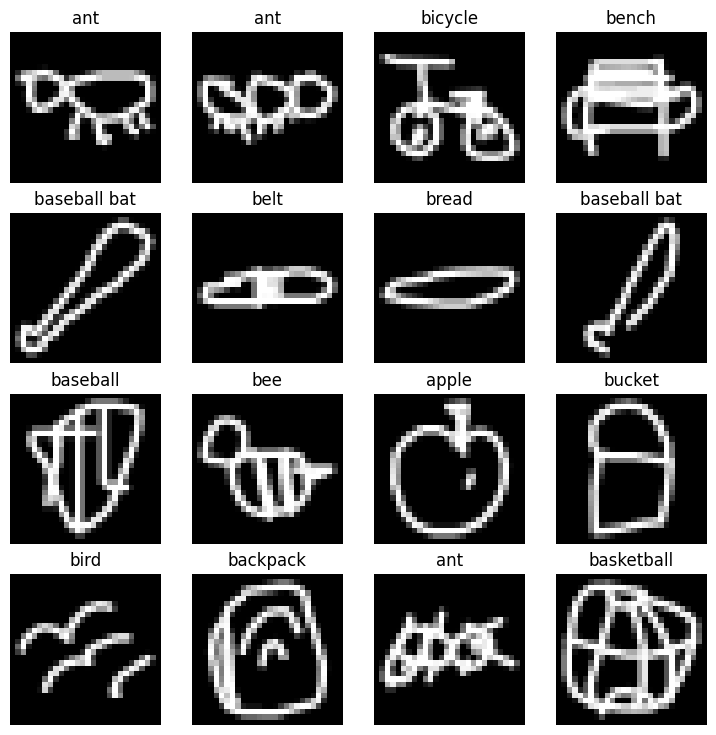

In [ ]:
cols, rows = 4,4
fig = plt.figure(figsize=(9,9))

for i in range(1, cols * rows + 1):
  img, labels = train_dataset[i]
  fig.add_subplot(cols, rows, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(dataset.class_names[labels])
  plt.axis(False)

In [ ]:
class_names = []

for file in PATH.iterdir():
  if file.suffix == '.npy': # Only consider .npy files
    class_names.append(file.stem)


In [ ]:
model_0 = Drawmodel(num_classes=len(dataset.class_names)).to(device)

next(model_0.parameters()).device


device(type='cuda', index=0)

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

In [ ]:
from tqdm import tqdm

In [ ]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {device}")
print(f"Model device: {next(model_0.parameters()).device if 'model_0' in locals() else 'Model not created yet'}")

CUDA available: True
Device: cuda
Model device: cuda:0


In [ ]:
len(dataset.class_names)

38

In [ ]:
epochs = 20

for epoch in range(epochs):
    model_0.train()
    train_loss = 0
    total_batches = 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        X = X.to(device)
        y = y.to(device)

        preds = model_0(X)
        loss = loss_fn(preds, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        train_loss += loss.item()
        total_batches += 1




    train_loss /= total_batches
    print(f"Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}")


    model_0.eval()
    with torch.inference_mode():
        total, correct = 0, 0
        for x_test, y_test in tqdm(test_loader, desc=f"Epoch {epoch+1}", leave=False):
            x_test, y_test = x_test.to(device), y_test.to(device)
            preds_test = model_0(x_test)
            predicted = torch.argmax(preds_test, dim=1)
            total += y_test.size(0)
            correct += (predicted == y_test).sum().item()
        print(f"Test Accuracy: {100*correct/total:.2f}%")

    if (epoch + 1) % 2 == 0:  # every 2 epochs
      torch.save(model_0.state_dict(), f"model_epoch{epoch+1}.pt")


Epoch: 1/20 | Train Loss: 0.4953


Test Accuracy: 88.70%


Epoch: 2/20 | Train Loss: 0.3861


Test Accuracy: 89.61%


Epoch: 3/20 | Train Loss: 0.3613


...

Test Accuracy: 90.87%


Epoch: 19/20 | Train Loss: 0.2846


Test Accuracy: 90.78%


Epoch: 20/20 | Train Loss: 0.2829


Test Accuracy: 90.85%


In [ ]:
x, y = train_dataset[1]

In [ ]:
x

In [ ]:
plt.imshow(x.squeeze().to(device="cpu"))

In [ ]:
plt.imshow(x_test[100].squeeze().to(device="cpu"))


In [ ]:
x_test[1], x_test[2]

In [ ]:
model_0.eval()
with torch.inference_mode():
  total, correct = 0, 0
  for x_test, y_test in tqdm(test_loader, desc=f"Epoch {epoch+1}", leave=False):
      x_test, y_test = x_test.to(device), y_test.to(device)
      preds_test = model_0(x_test)
      predicted = torch.argmax(preds_test, dim=1)
      total += y_test.size(0)
      correct += (predicted == y_test).sum().item()
  print(f"Test Accuracy: {100*correct/total:.2f}%")

In [ ]:
class BetterDrawModel(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Expanded first layer
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  # Two convs before pooling
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Use residual-like blocks
            self._make_block(64, 128),
            self._make_block(128, 256),
            self._make_block(256, 512),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def _make_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

In [ ]:
x_test[1]